### Подготовка данных


In [7]:
import os
import shutil
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [14]:
home = '/home/slava/Downloads/Diplom9/Diplom'

def merge_folders(src_folder, dst_folder, prefix):
    os.makedirs(dst_folder, exist_ok=True)
    for fname in os.listdir(src_folder):
        src_path = os.path.join(src_folder, fname)
        if os.path.isfile(src_path):
            new_name = prefix + fname
            dst_path = os.path.join(dst_folder, new_name)
            shutil.copy2(src_path, dst_path)

# Копируем expected
merge_folders(home + '/diff_spot_bunner_expected', 'NN_8K_merged/expected', 'set1_')
merge_folders(home + '/diff_spot_expected',        'NN_8K_merged/expected', 'set2_')

# Копируем actual
merge_folders(home + '/diff_spot_bunner_actual',   'NN_8K_merged/actual',   'set1_')
merge_folders(home + '/diff_spot_actual',          'NN_8K_merged/actual',   'set2_')

# Копируем diff
merge_folders(home + '/diff_spot_bunner_diff',     'NN_8K_merged/diff',     'set1_')
merge_folders(home + '/diff_spot_diff',            'NN_8K_merged/diff',     'set2_')

In [15]:
merged_expected_path = 'NN_8K_merged/expected'
file_ids = []
labels = []

# Определяем расширение файлов (скорее всего .png, но можно уточнить)
extensions = ('.png', '.jpg', '.jpeg')  # добавьте нужные

for fname in sorted(os.listdir(merged_expected_path)):
    if fname.lower().endswith(extensions):
        file_id = os.path.splitext(fname)[0]  # убираем расширение
        file_ids.append(file_id)
        
        # Определяем метку по префиксу
        if file_id.startswith('set1_'):
            labels.append(0)   # bunner -> 0
        elif file_id.startswith('set2_'):
            labels.append(1)   # без bunner -> 1
        else:
            raise ValueError(f"Неизвестный префикс у файла: {file_id}")

# Проверка: количество файлов должно совпадать во всех трёх папках
# (необязательно, но полезно)
actual_files = set(os.listdir('NN_8K_merged/actual'))
diff_files  = set(os.listdir('NN_8K_merged/diff'))
expected_set = set(os.listdir(merged_expected_path))

if not (expected_set == actual_files == diff_files):
    print("Внимание! Наборы файлов в папках не совпадают.")
    print(f"Expected: {len(expected_set)}, Actual: {len(actual_files)}, Diff: {len(diff_files)}")
    # Можно дополнительно найти различия
else:
    print(f"Все три папки содержат {len(file_ids)} файлов, порядок сохранён.")

# Сохраняем метки и идентификаторы
joblib.dump(file_ids, 'NN_8K_merged_file_ids.joblib')
joblib.dump(labels, 'NN_8K_merged_labels.joblib')

print("Готово! Файлы с метками сохранены.")

Внимание! Наборы файлов в папках не совпадают.
Expected: 7548, Actual: 7548, Diff: 7548
Готово! Файлы с метками сохранены.


In [20]:
import pathlib


dir_path = pathlib.Path('/home/slava/Downloads/Diplom9/Diplom/NN_8K_merged/actual')
if not dir_path.is_dir():
    print(f"Error: {directory} is not a directory.")
for file_path in dir_path.iterdir():
    if file_path.is_file():
        old_name = file_path.name
        if "_aug" in old_name:
            new_name = old_name.replace("_aug", "")
            new_path = file_path.with_name(new_name)
            if new_path.exists():
                print(f"Skipping {old_name} -> {new_name} because target already exists.")
            else:
                file_path.rename(new_path)
                print(f"Renamed {old_name} to {new_name}")

Renamed set1_aug_img_001177.jpg to set1_img_001177.jpg
Renamed set1_aug_img_001688.jpg to set1_img_001688.jpg
Renamed set1_aug_img_000929.jpg to set1_img_000929.jpg
Renamed set1_aug_img_001883.jpg to set1_img_001883.jpg
Renamed set1_aug_img_003578.jpg to set1_img_003578.jpg
Renamed set1_aug_img_002751.jpg to set1_img_002751.jpg
Renamed set1_aug_img_000074.jpg to set1_img_000074.jpg
Renamed set1_aug_img_002979.jpg to set1_img_002979.jpg
Renamed set1_aug_img_000229.jpg to set1_img_000229.jpg
Renamed set1_aug_img_001274.jpg to set1_img_001274.jpg
Renamed set1_aug_img_001862.jpg to set1_img_001862.jpg
Renamed set1_aug_img_003330.jpg to set1_img_003330.jpg
Renamed set1_aug_img_003733.jpg to set1_img_003733.jpg
Renamed set1_aug_img_003484.jpg to set1_img_003484.jpg
Renamed set1_aug_img_000734.jpg to set1_img_000734.jpg
Renamed set1_aug_img_000244.jpg to set1_img_000244.jpg
Renamed set1_aug_img_002367.jpg to set1_img_002367.jpg
Renamed set1_aug_img_001061.jpg to set1_img_001061.jpg
Renamed se

                                              actual  \
0  /home/slava/Downloads/Diplom9/Diplom/diff_spot...   
1  /home/slava/Downloads/Diplom9/Diplom/diff_spot...   
2  /home/slava/Downloads/Diplom9/Diplom/diff_spot...   
3  /home/slava/Downloads/Diplom9/Diplom/diff_spot...   
4  /home/slava/Downloads/Diplom9/Diplom/diff_spot...   

                                            expected            filename  \
0  /home/slava/Downloads/Diplom9/Diplom/diff_spot...  aug_img_000713.jpg   
1  /home/slava/Downloads/Diplom9/Diplom/diff_spot...  aug_img_001974.jpg   
2  /home/slava/Downloads/Diplom9/Diplom/diff_spot...  aug_img_002659.jpg   
3  /home/slava/Downloads/Diplom9/Diplom/diff_spot...  aug_img_002154.jpg   
4  /home/slava/Downloads/Diplom9/Diplom/diff_spot...  aug_img_000966.jpg   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  
Всего пар: 7548
С багами: 3774
Без багов: 3774


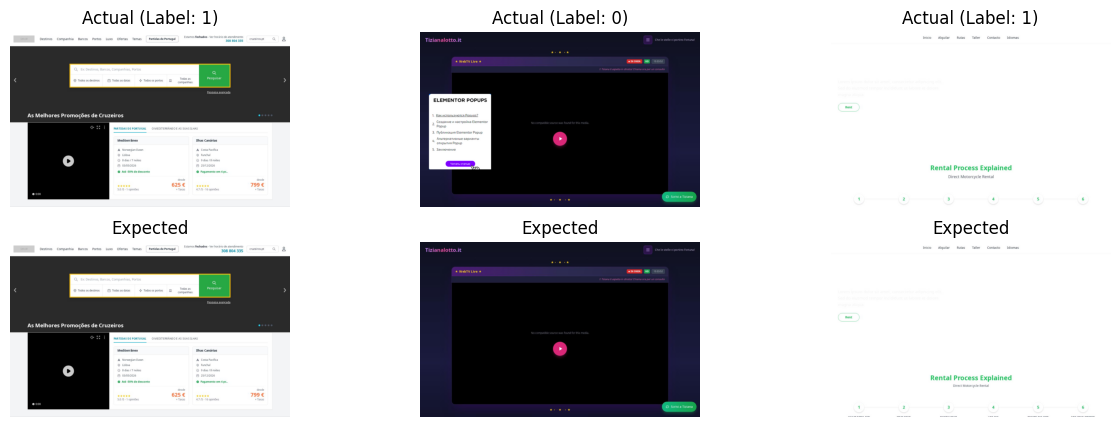

In [10]:
print(df.head())
print(f"Всего пар: {len(df)}")
print(f"С багами: {df['label'].sum()}")
print(f"Без багов: {len(df) - df['label'].sum()}")

def show_samples(df, n=3):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        row = df.sample().iloc[0]
        actual_img = Image.open(row['actual'])
        expected_img = Image.open(row['expected'])
        plt.subplot(2, n, i+1)
        plt.imshow(actual_img)
        plt.title(f'Actual (Label: {row["label"]})')
        plt.axis('off')
        plt.subplot(2, n, n+i+1)
        plt.imshow(expected_img)
        plt.title('Expected')
        plt.axis('off')
    plt.show()

show_samples(df)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7548 entries, 0 to 7547
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   actual    7548 non-null   str  
 1   expected  7548 non-null   str  
 2   filename  7548 non-null   str  
 3   label     7548 non-null   int64
dtypes: int64(1), str(3)
memory usage: 236.0 KB


In [13]:
IMG_SIZE = (512, 256)  # до какого размера сжимаем изображения

def compress_image(path):
    img = Image.open(path).convert('L')  # конвертируем в grayscale
    img = img.resize(IMG_SIZE)  # сжимаем
    return np.array(img) / 255.0  # нормализация

X = []
y = []
actual_images = []
expected_images = []

for _, row in df.iterrows():
    actual = compress_image(row['actual'])
    expected = compress_image(row['expected'])
    actual_images.append(actual)
    expected_images.append(expected)

    # Вычисляем абсолютную разницу (в градациях серого)
    diff = np.abs(actual - expected)  # форма: (h, w)
    
    X.append(diff)
    y.append(row['label'])

joblib.dump(y, 'y_labels_6_overeducation4.joblib')

X = np.array(X)  # вертор разницы
y = np.array(y)  # метки: 0 или 1

KeyboardInterrupt: 

In [ ]:
print(f"Форма X: {X.shape}")
print(f"Тип данных X: {X.dtype}")
print(f"Количество образцов: {len(X)}")
print(f"Диапазон значений: min={X.min():.4f}, max={X.max():.4f}")
print(f"Среднее значение: {X.mean():.4f}")
print(f"Стандартное отклонение: {X.std():.4f}")

### Анализ
Мы сжали изображения и вывели их разницу. 
Явно видно, что у нас большая часть данных - это нулевые значения (черный фон).
Вырежем изменения, так как позиция места разницы не несет значимых признаков.

Размеры до обрезки: (256, 512)
Размеры после обрезки: (59, 115)
Пример координат: (np.int64(33), np.int64(259))
Средний размер после обрезки: 198.2762836185819


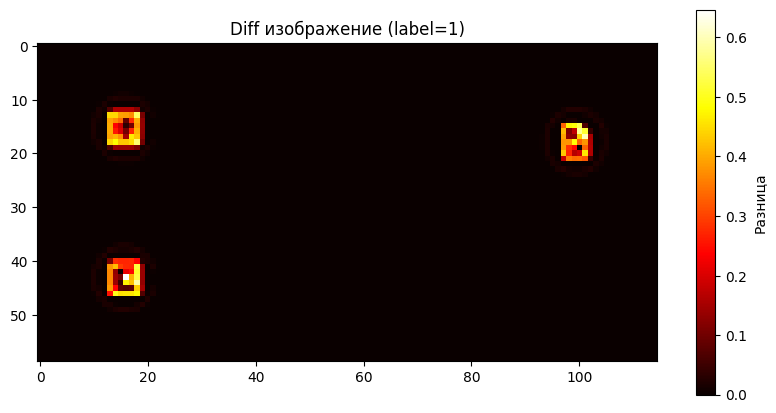

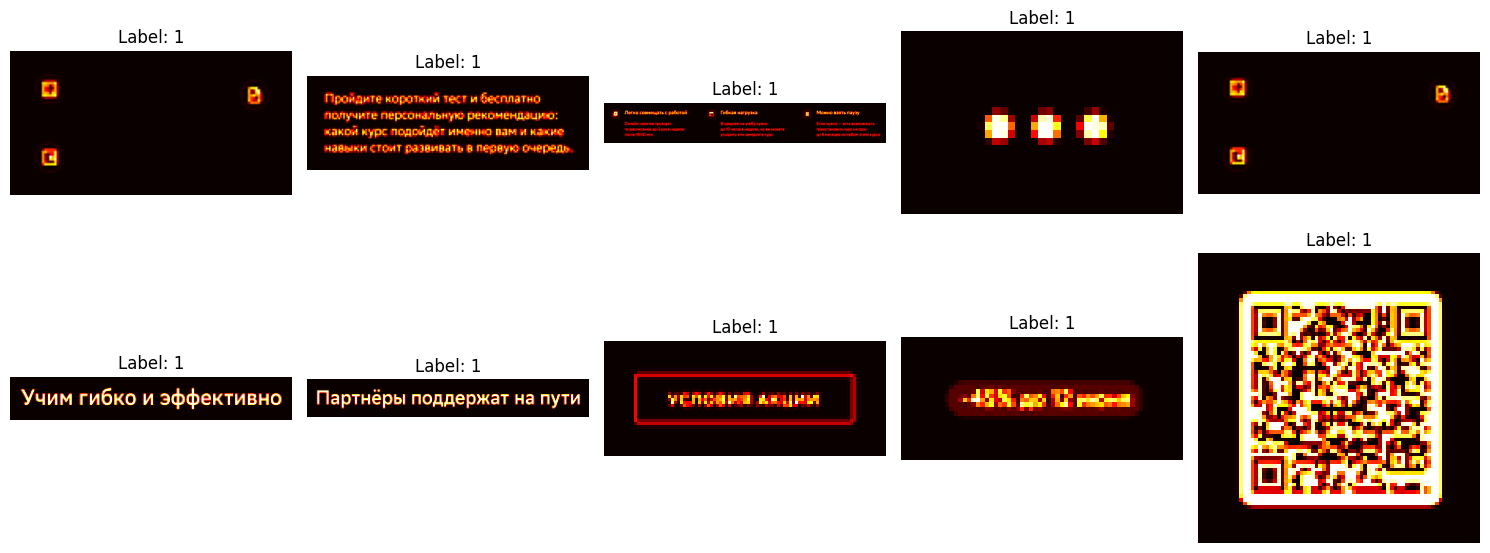

In [9]:
def crop_to_content_with_coords(image, threshold=0.01):
    """
    Обрезает изображение до области с информацией и возвращает координаты.
    
    Returns:
        cropped: обрезанное изображение
        top_left: кортеж (y, x) — координаты верхнего левого угла обрезанной области 
                  относительно исходного изображения (до применения padding)
    """
    mask = image > threshold
    
    if not mask.any():
        return np.zeros((10, 10)), (0, 0)
    
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    
    # Сохраняем координаты ДО добавления padding
    top_left_y = rmin
    top_left_x = cmin
    
    padding = 10
    rmin = max(0, rmin - padding)
    rmax = min(image.shape[0], rmax + padding)
    cmin = max(0, cmin - padding)
    cmax = min(image.shape[1], cmax + padding)
    
    cropped = image[rmin:rmax, cmin:cmax]
    top_left = (top_left_y, top_left_x)
    
    return cropped, top_left

X_cropped = []
X_coords = []
for img in X:
    cropped, coords = crop_to_content_with_coords(img)
    X_cropped.append(cropped)
    X_coords.append(coords)

# Проверяем результаты
print(f"Размеры до обрезки: {X[0].shape}")
print(f"Размеры после обрезки: {X_cropped[0].shape}")
print(f"Пример координат: {X_coords[0]}")
print(f"Средний размер после обрезки: {np.mean([img.shape for img in X_cropped])}")

# Визуализация первого diff-изображения
plt.figure(figsize=(10, 5))
plt.imshow(X_cropped[0], cmap='hot')
plt.colorbar(label='Разница')
plt.title(f'Diff изображение (label={y[0]})')
plt.show()

# Сравнение нескольких образцов
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X_cropped):
        ax.imshow(X_cropped[i], cmap='hot')
        ax.set_title(f'Label: {y[i]}')
        ax.axis('off')
plt.tight_layout()
plt.show()

## Анализ
Мы максимально уменьшили объем данных отбросив лишнее. Даже на глаз понятно, что для пропадающих элементов дефект выглядит явно и не составит труда его классифицировать, то как же обстоят дела со сдвигом и динамическими элементами?

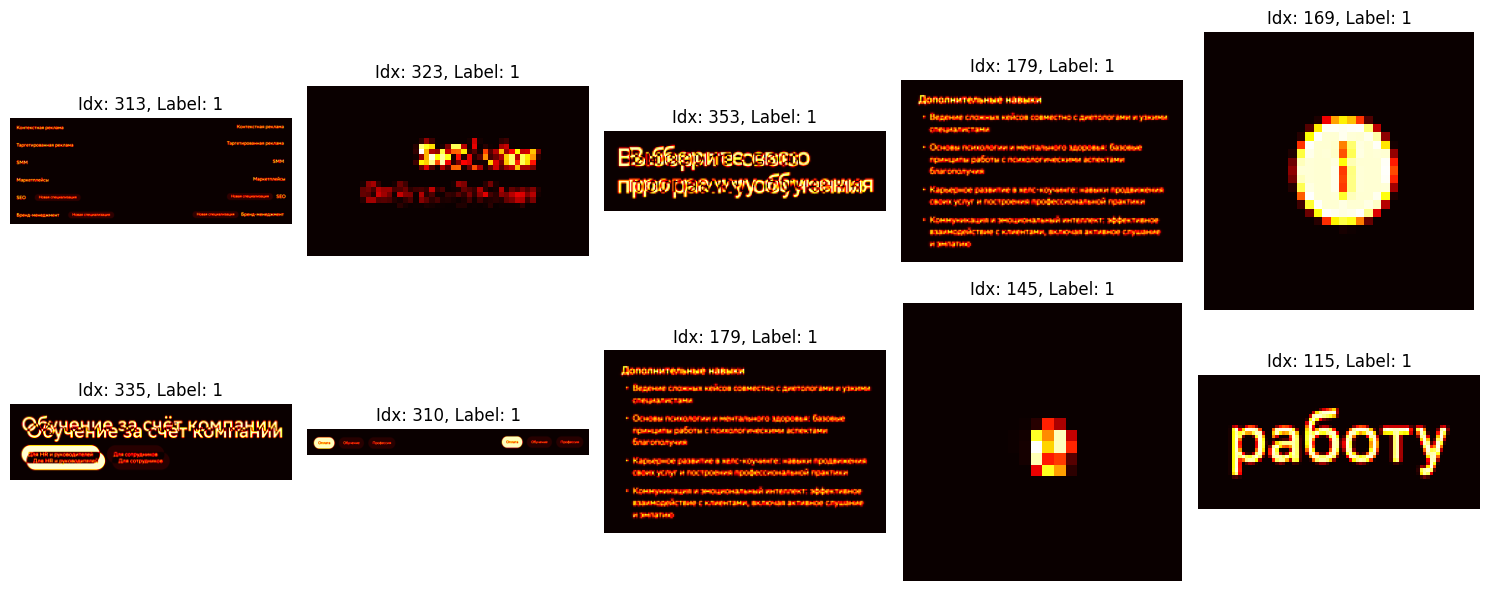

In [10]:
# индексы для анализа
indices = [313, 323, 353, 179, 169, 335, 310, 179, 145, 115]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(indices):
        idx = indices[i]
        if idx < len(X_cropped):
            ax.imshow(X_cropped[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

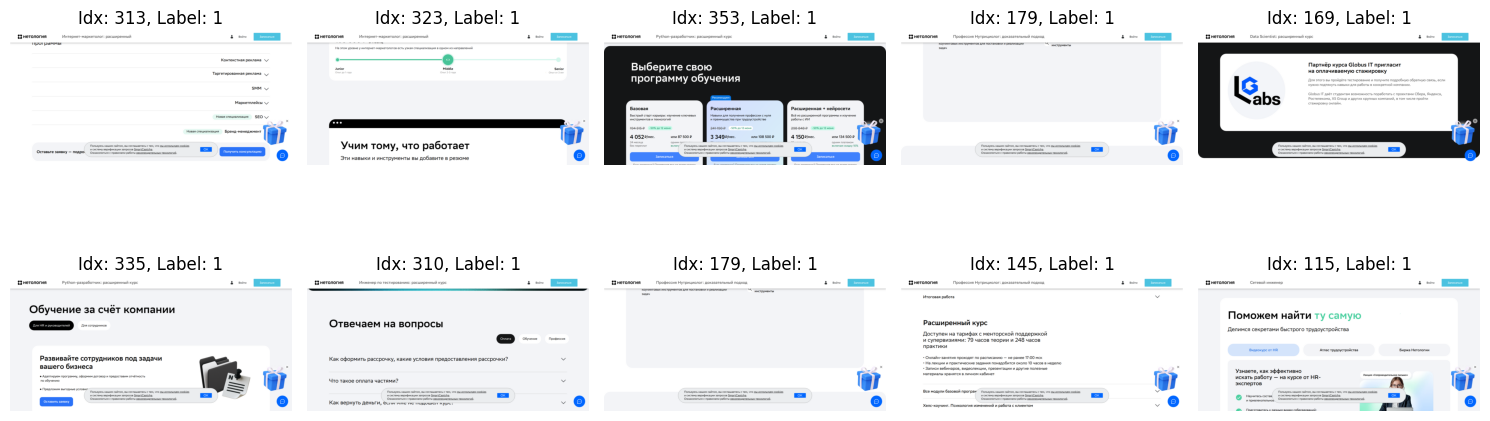

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flat

for i, ax in enumerate(axes):
    if i < len(indices):
        idx = indices[i]
        row = df.loc[idx]  # Получаем строку по индексу
        actual_img = Image.open(row['actual'])
        expected_img = Image.open(row['expected'])
        
        ax.imshow(np.array(actual_img))
        ax.set_title(f'Idx: {idx}, Label: {row["label"]}')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

### Анализ
Баннер на 313 и 310 выделен отдельно, что не составляет труда понять, что этот элемент допустим.

323, 335 и 353 сдвиг + баннер явно видно, что элементы сдвинуты немного.

179, 169, 175 виден сдвиг и оба элемента.

115 изменение цвета тоже попало

In [12]:
joblib.dump(X_cropped, 'X_cropped_diff_images_2_increase_ds.joblib')
joblib.dump(X_coords, 'X_coords_diff_images_2_increase_ds.joblib')
joblib.dump(y, 'y_labels_2_increase_ds.joblib')

['y_labels_2_increase_ds.joblib']